In [1]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline

import math
import tensorflow
from tensorflow.compat.v1.keras.backend import get_session
tensorflow.compat.v1.disable_v2_behavior()
import kerasAC 
from kerasAC.generators.snp_generator import *
from kerasAC.tiledb_config import *
from scipy.special import softmax
from kerasAC.interpret.deepshap import * 
from kerasAC.interpret.profile_shap import * 
from kerasAC.vis import * 
from kerasAC.helpers.transform_bpnet_io import * 

Instructions for updating:
non-resource variables are not supported in the long term


Using TensorFlow backend.
/users/annashch/kerasAC/kerasAC/vis/plot_letters.py:172: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  min_coords = np.vstack(data.min(0) for data in polygons_data).min(0)
/users/annashch/kerasAC/kerasAC/vis/plot_letters.py:173: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  max_coords = np.vstack(data.max(0) for data in polygons_data).max(0)


In [2]:
import pyBigWig 
pbw=pyBigWig.open("/oak/stanford/groups/akundaje/projects/atlas/dnase_processed/dnase/13da5ebe-0941-4855-8599-40bbcc5c58b4/call-bowtie2/shard-0/execution/ENCSR000EMT.merged.bam.bpnet.unstranded.bw",'r')

In [3]:
#make sure the snp coordinate is 0-based
import pandas as pd 
snps=pd.read_csv("/srv/scratch/annashch/chrombpnet/gm12878_dnase/bQTL/nfkB.txt",header=0,sep='\t')
#keep1=snps.iloc[0:100]
#keep2=snps.iloc[999699:999800]
#snps=pd.concat((keep1,keep2),axis=0)
snps['Pos0']=snps['position']-1
snps['rsid']=snps['Chr'].astype(str)+'_'+snps['Pos0'].astype(str)+'_'+snps['POSTallele'].astype(str)+'_'+snps['ALTallele'].astype('str')
snps.to_csv("nfkB.formatted.csv",header=True,index=False,sep='\t')
snps['logratio']=np.log((snps['POSTfreq']+.01)/(snps['prechipfreq']+0.01))
snps.head() 

,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,POSTallele,POSTfreq,prechipfreq,pvalue,Pos0,rsid,logratio
0,chr11,30344883,908,117,791,C,G,0.871145,0.509946,3.229090e-115,30344882,chr11_30344882_G_C,0.527498
1,chr3,192616700,291,39,252,G,T,0.865979,0.345095,1.128018e-75,192616699,chr3_192616699_T_G,0.902957
2,chr1,149577335,127,107,20,C,G,0.157480,0.849838,3.141112e-67,149577334,chr1_149577334_G_C,-1.635879
3,chr1,145209819,153,70,83,T,C,0.542484,0.928303,7.448239e-39,145209818,chr1_145209818_C_T,-0.529649
4,chr4,133045472,312,248,64,A,C,0.205128,0.551773,4.458003e-36,133045471,chr4_133045471_C_A,-0.959863


In [9]:
snps.shape

(1880520, 13)

In [4]:
#reference allele sequence generator 
ref_gen=SNPGenerator(bed_path="nfkB.formatted.csv",
                 chrom_col="Chr",
                 pos_col="Pos0",
                 allele_col="POSTallele",
                 rsid_col='rsid',
                 flank_size=673,
                 ref_fasta="/mnt/data/male.hg19.fa",
                 expand_dims=False)

#alternate allele sequence generator 
alt_gen=SNPGenerator(bed_path="nfkB.formatted.csv",
                 chrom_col="Chr",
                 pos_col="Pos0",
                 allele_col="ALTallele",
                 rsid_col='rsid',
                 flank_size=673,
                 ref_fasta="/mnt/data/male.hg19.fa",
                 expand_dims=False)


In [5]:
#load the model! 
from keras.models import load_model
from keras.utils.generic_utils import get_custom_objects
from kerasAC.metrics import * 
from kerasAC.custom_losses import * 
custom_objects={"recall":recall,
                    "sensitivity":recall,
                    "specificity":specificity,
                    "fpr":fpr,
                    "fnr":fnr,
                    "precision":precision,
                    "f1":f1,
                    "ambig_binary_crossentropy":ambig_binary_crossentropy,
                    "ambig_mean_absolute_error":ambig_mean_absolute_error,
                    "ambig_mean_squared_error":ambig_mean_squared_error,
                    "MultichannelMultinomialNLL":MultichannelMultinomialNLL}
get_custom_objects().update(custom_objects)
model=load_model("/srv/scratch/annashch/chrombpnet/gm12878_dnase/with_bias_unplugged/gm12878.dnase.with.bias.unplugged.0.hdf5")

Instructions for updating:
If using Keras pass *_constraint arguments to layers.


In [6]:
#get the reference allele predictions 
count_preds={} 
profile_preds={} 
snp_to_seq={} 
for i in range(len(ref_gen)):
    print(str(i))
    cur_x=ref_gen[i] 
    batch_rsids=cur_x[0] 
    batch_preds=model.predict(cur_x[1])
    batch_preds_profile=batch_preds[0]
    batch_preds_count=batch_preds[1] 
    for batch_index in range(len(batch_rsids)): 
        cur_rsid=batch_rsids[batch_index]
        snp_to_seq[cur_rsid]={} 
        snp_to_seq[cur_rsid]['ref']=cur_x[1][batch_index,:,:]
        cur_pred_profile=batch_preds_profile[batch_index,:,:]
        cur_pred_count=batch_preds_count[batch_index,:][0]
        count_preds[cur_rsid]={}
        count_preds[cur_rsid]['ref']=cur_pred_count
        profile_preds[cur_rsid]={}
        profile_preds[cur_rsid]['ref']=cur_pred_profile 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [7]:
#get the alternate allele predictions 
for i in range(len(alt_gen)):
    print(str(i))
    cur_x=alt_gen[i] 
    batch_rsids=cur_x[0] 
    batch_preds=model.predict(cur_x[1])
    batch_preds_profile=batch_preds[0]
    batch_preds_count=batch_preds[1] 
    for batch_index in range(len(batch_rsids)): 
        cur_rsid=batch_rsids[batch_index]
        snp_to_seq[cur_rsid]['alt']=cur_x[1][batch_index,:,:]
        cur_pred_profile=batch_preds_profile[batch_index,:,:]
        cur_pred_count=batch_preds_count[batch_index,:][0]
        count_preds[cur_rsid]['alt']=cur_pred_count
        profile_preds[cur_rsid]['alt']=cur_pred_profile 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [8]:
#convert dictionary to pandas df for easier manipulation 
count_preds_df=pd.DataFrame.from_dict(count_preds,orient='index')
count_preds_df['Alt_Minus_Ref']=count_preds_df['alt']-count_preds_df['ref']
#sort by difference 
count_preds_df=count_preds_df.sort_values(by=["Alt_Minus_Ref"])
count_preds_df.to_csv("nfkB_count_predictions_alt_and_ref.tsv",header=True,index=True,sep='\t')

print(count_preds_df.head())
print(count_preds_df.tail())

                         ref       alt  Alt_Minus_Ref
chr10_5894499_A_G   5.810127  5.128612      -0.681515
chr14_90348414_C_T  5.143096  4.506055      -0.637041
chr18_10213741_T_G  5.284908  4.651841      -0.633068
chr6_8627860_C_T    5.201197  4.577322      -0.623875
chr10_97701094_A_C  4.949368  4.345614      -0.603754
                         ref       alt  Alt_Minus_Ref
chr1_107977227_A_C  4.361895  5.014132       0.652238
chr5_102117225_A_C  4.527899  5.180937       0.653038
chr17_53495972_C_T  4.515101  5.175626       0.660525
chr4_90465825_A_C   4.477476  5.200108       0.722632
chr18_45206448_G_A  4.445184  5.174126       0.728942


In [9]:
from scipy.special import softmax,logit,softmax
from scipy.spatial.distance import jensenshannon
#get the JSD for profile preds 
jsd_dict={} 
for rsid in profile_preds: 
    ref_preds=softmax(profile_preds[rsid]['ref'],axis=0)
    alt_preds=softmax(profile_preds[rsid]['alt'],axis=0)
    cur_jsd=jensenshannon(ref_preds.squeeze(),alt_preds.squeeze())
    jsd_dict[rsid]=cur_jsd
jsd_df=pd.DataFrame.from_dict(jsd_dict,orient='index')
jsd_df.head()
#sort by difference 
jsd_df=jsd_df.sort_values(by=[0])
jsd_df.to_csv("nfkB_jsd_predictions.tsv",header=True,index=True,sep='\t')

print(jsd_df.head())
print(jsd_df.tail())


                           0
chr20_5654596_G_C   0.001454
chr8_80935692_T_C   0.001472
chr12_72411307_G_A  0.001646
chr7_111720255_A_C  0.001758
chr2_33496895_C_T   0.001767
                           0
chr6_70197788_C_G   0.310218
chr7_143187993_G_C  0.311068
chr5_162900838_G_A  0.346598
chr6_25223878_C_T   0.349699
chr8_11137204_G_C   0.352825


In [10]:
jsd_df['JSD']=jsd_df[0]
jsd_df=jsd_df.drop(columns=[0])


In [11]:
#merge the data frames
merged=pd.merge(jsd_df,count_preds_df,left_index=True,right_index=True)
merged=pd.merge(merged,snps,left_index=True,right_on=['rsid'])
merged['-log10P']=-1*np.log10(merged['pvalue'])

In [12]:
merged['sig']=merged['pvalue']<5e-5

In [13]:
merged.shape

(1554632, 19)

In [14]:
merged['color']='r'
merged['color'][merged['sig']==True]='b'
merged['abs_logratio']=np.abs(merged['logratio'])
merged['abs_Alt_Minus_Ref']=np.abs(merged['Alt_Minus_Ref'])


In [15]:
%matplotlib inline

from plotnine import * 


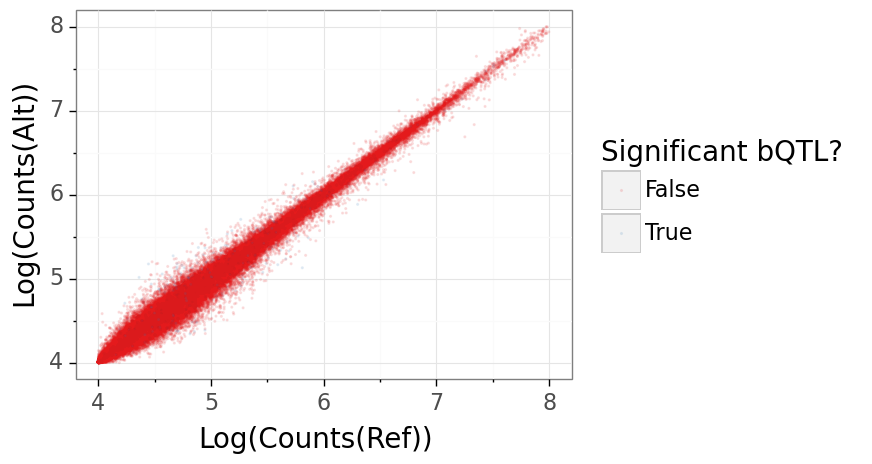

<ggplot: (8741202655221)>

In [16]:
(ggplot(merged, aes('ref', 'alt', color='factor(sig)'))
 + geom_point(alpha=0.1,size=0.3)
 + xlim(4,8)
 + ylim(4,8)
 + xlab("Log(Counts(Ref))")
 + ylab("Log(Counts(Alt))")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))


In [17]:
from kerasAC.vis.density_scatter import * 
sig=merged[merged['sig']==True]
nonsig=merged[merged['sig']==False]

Text(0.5, 1.0, 'P-val <= 5e-5')

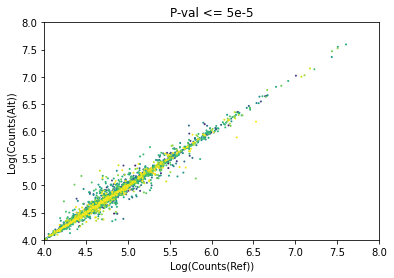

In [18]:
density_scatter(sig['ref'],sig['alt'],xlab='Log(Counts(Ref))',ylab='Log(Counts(Alt))',xlim=(4,8),ylim=(4,8),s=1)
plt.title("P-val <= 5e-5")

In [19]:
nonsig.head()

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,...,prechipfreq,pvalue,Pos0,rsid,logratio,-log10P,sig,color,abs_logratio,abs_Alt_Minus_Ref
308496,0.001454,5.313743,5.309432,-0.004311,chr20,5654597,22,7,15,C,...,0.796753,0.186451,5654596,chr20_5654596_G_C,-0.153694,0.729435,False,r,0.153694,0.004311
1468408,0.001472,4.272111,4.275629,0.003518,chr8,80935693,22,1,21,C,...,0.932003,1.000000,80935692,chr8_80935692_T_C,0.023648,-0.000000,False,r,0.023648,0.003518
801970,0.001646,4.471915,4.472522,0.000607,chr12,72411308,22,0,22,A,...,0.956238,0.623811,72411307,chr12_72411307_G_A,0.044296,0.204947,False,r,0.044296,0.000607
247085,0.001758,5.284072,5.287243,0.003170,chr7,111720256,40,20,20,C,...,0.387012,0.147114,111720255,chr7_111720255_A_C,0.250443,0.832345,False,r,0.250443,0.003170
100003,0.001767,5.464542,5.465073,0.000531,chr2,33496896,27,0,27,T,...,0.862253,0.043507,33496895,chr2_33496895_C_T,0.146626,1.361445,False,r,0.146626,0.000531


Text(0.5, 1.0, 'P-val > 5e-5')

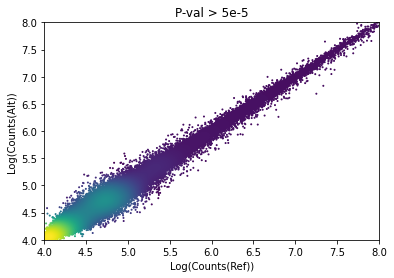

In [20]:
density_scatter(nonsig['ref'].values,nonsig['alt'].values,xlab='Log(Counts(Ref))',ylab='Log(Counts(Alt))',xlim=(4,8),ylim=(4,8),s=1)
plt.title("P-val > 5e-5")

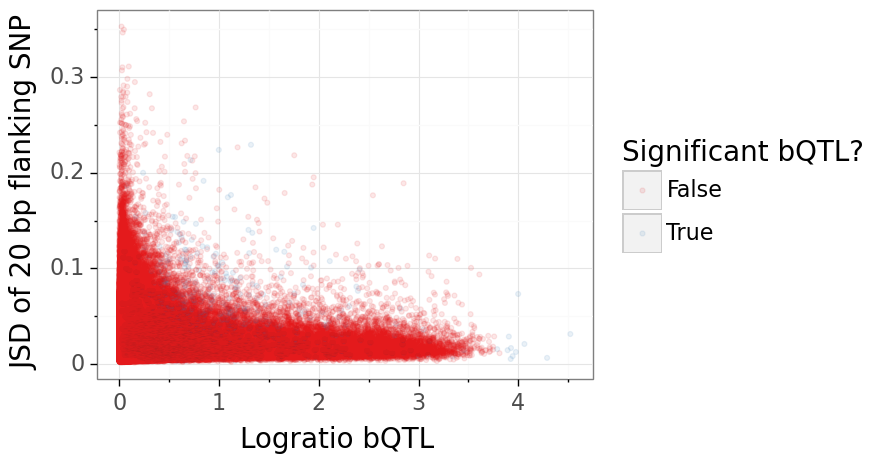

<ggplot: (8741189707989)>

In [21]:
(ggplot(merged, aes('abs_logratio', 'JSD', color='factor(sig)'))
 + geom_point(alpha=0.1)
 + xlab("Logratio bQTL")
 + ylab("JSD of 20 bp flanking SNP")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))

In [22]:
import scipy

scipy.stats.spearmanr(merged['abs_logratio'],merged['abs_Alt_Minus_Ref'])

SpearmanrResult(correlation=-0.014039663619635824, pvalue=1.2852022723242318e-68)

In [23]:
merged=merged[merged['abs_logratio']<np.inf]

In [24]:
scipy.stats.pearsonr(merged['abs_logratio'],merged['abs_Alt_Minus_Ref'])

(0.0012561966983249146, 0.11728150346584824)

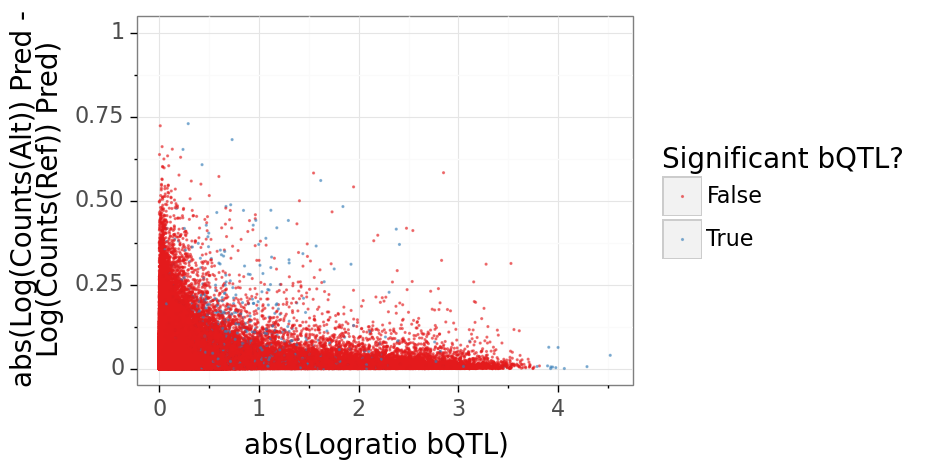

<ggplot: (8741190089469)>

In [25]:
(ggplot(merged, aes('abs_logratio', 'abs_Alt_Minus_Ref', color='factor(sig)'))
 + geom_point(alpha=0.5,size=0.3)
 + ylim(0,1)
 + xlab("abs(Logratio bQTL)")
 + ylab("abs(Log(Counts(Alt)) Pred -\nLog(Counts(Ref)) Pred)")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))


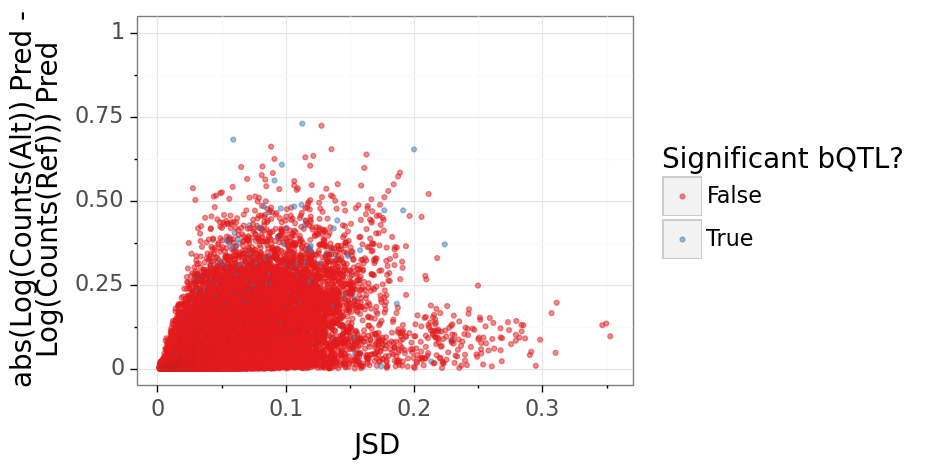

<ggplot: (8741189714533)>

In [26]:
(ggplot(merged, aes('JSD', 'abs_Alt_Minus_Ref', color='factor(sig)'))
 + geom_point(alpha=0.5)
 + ylim(0,1)
 + xlab("JSD")
 + ylab("abs(Log(Counts(Alt)) Pred -\nLog(Counts(Ref))) Pred")
 + scale_color_manual(values=['#e41a1c','#377eb8'],name="Significant bQTL?")
 + theme_bw(20))


In [27]:
prof_output = model.output[0]  # Shape: B x T x O x 2 (logits)                                                                                                       
logits = prof_output - tf.reduce_mean(prof_output, axis=1, keepdims=True)
logits_stopgrad=tf.stop_gradient(logits)
probs=tf.nn.softmax(logits_stopgrad,axis=1)
logits_weighted=logits*probs 
prof_sum=tf.reduce_sum(logits_weighted,axis=(1,2))
prof_explainer=shap.DeepExplainer(model=(model.input,prof_sum),data=create_background_atac,combine_mult_and_diffref=combine_mult_and_diffref_1d)


In [28]:
#get shap values for the SNPs with the highest delta 

#create the explainers 
model_wrapper=(model.input, model.outputs[1])
count_explainer=shap.DeepExplainer(model_wrapper,data=create_background_atac,combine_mult_and_diffref=combine_mult_and_diffref_1d)
#prof_explainer = create_explainer(model,ischip=False)

In [29]:
model.output[0]

<tf.Tensor 'profile_predictions/add:0' shape=(?, 1000, 1) dtype=float32>

In [30]:
## for plotting 
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5
plt.rcParams['axes.xmargin'] = 0

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
def make_plot(rsid,
              count_pred_ref,
              count_pred_alt,
              pred_prob_ref,
              pred_prob_alt,
              profile_explanations_ref, 
              seq_ref,
              profile_explanations_alt,
              seq_alt,
              count_explanations_ref, 
              count_explanations_alt,
              xmin=0,
              xmax=1000,
              ymin_prof_shap=-0.1,
              ymin_count_shap=-0.1,
              ymin_perf=-0.1,
              ymax_prof_shap=0.1,
              ymax_count_shap=0.1,
              ymax_perf=0.1):
    plt.rcParams["figure.figsize"]=20,10
    fig, axes = plt.subplots(7, 1)
    axes[0].plot(np.exp(count_pred_ref)*pred_prob_ref,label='Ref pred counts per base',color='b')
    axes[0].plot(np.exp(count_pred_alt)*pred_prob_alt,label='Alt pred counts per base',color='r')
    axes[0].set_title(str(rsid)+"Counts Pred Ref:"+str(count_pred_ref)+":"+"Counts Pred Alt:"+str(count_pred_alt))
    axes[0].legend() 
    axes[0].set_xlim(xmin,xmax)
    #axes[0].set_ylim(ymin_perf,ymax_perf)
    axes[0].set_xticks(list(range(xmin, xmax, 50,)))    
    
    axes[1].plot(np.exp(count_pred_ref)*pred_prob_ref-np.exp(count_pred_alt)*pred_prob_alt,label='Difference in predicted counts per base (Ref - Alt)',color='k')
    axes[1].legend() 
    axes[1].set_xlim(xmin,xmax)
    #axes[1].set_ylim(ymin_perf,ymax_perf)
    axes[1].set_xticks(list(range(xmin, xmax, 50,)))    
    
    axes[2].plot(np.log(pred_prob_ref)-np.log(pred_prob_alt),label='Log(Prob Ref)-Log(Prof Alt)',color='k')
    axes[2].legend() 
    axes[2].set_xlim(xmin,xmax)
    #axes[2].set_ylim(ymin_perf,ymax_perf)
    axes[2].set_xticks(list(range(xmin, xmax, 50,)))    
    
    
    axes[3]=plot_seq_importance(profile_explanations_ref,seq_ref,xlim=(xmin,xmax),axes=axes[3])
    axes[3].set_title("Profile Loss SHAP, Ref")        
    axes[3].set_ylim(ymin_prof_shap,ymax_prof_shap)
    axes[3].set_xticks(list(range(xmin, xmax, 50,)))    

    axes[4]=plot_seq_importance(profile_explanations_alt,seq_alt,xlim=(xmin,xmax),axes=axes[4])
    axes[4].set_title("Profile Loss SHAP, Alt")        
    axes[4].set_ylim(ymin_prof_shap,ymax_prof_shap)
    axes[4].set_xticks(list(range(xmin, xmax, 50,)))    
        
    axes[5]=plot_seq_importance(count_explanations_ref,seq_ref,xlim=(xmin,xmax),axes=axes[5])
    axes[5].set_title("Count Loss SHAP, Ref")        
    axes[5].set_ylim(ymin_count_shap,ymax_count_shap)
    axes[5].set_xticks(list(range(xmin, xmax, 50,)))    

    axes[6]=plot_seq_importance(count_explanations_alt,seq_alt,xlim=(xmin,xmax),axes=axes[6])
    axes[6].set_title("Count Loss SHAP, Alt")        
    axes[6].set_ylim(ymin_count_shap,ymax_count_shap)
    axes[6].set_xticks(list(range(xmin, xmax, 50,))) 

    plt.subplots_adjust(hspace=0.6)
    plt.show()

In [32]:
sig=merged[merged['sig']==True]
sig=sig.sort_values(by=['logratio'])
sig.head()

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,...,prechipfreq,pvalue,Pos0,rsid,logratio,-log10P,sig,color,abs_logratio,abs_Alt_Minus_Ref
26,0.031330,5.424309,5.463849,0.039540,chr9,107690535,23,23,0,C,...,0.910795,7.226754e-25,107690534,chr9_107690534_G_C,-4.522652,24.141057,True,b,4.522652,0.039540
398,0.006362,5.472322,5.478162,0.005839,chr1,244463241,16,16,0,T,...,0.719301,1.485466e-09,244463240,chr1_244463240_G_T,-4.289501,8.828137,True,b,4.289501,0.005839
1056,0.020914,5.031884,5.031696,-0.000188,chr15,41047024,16,16,0,A,...,0.571045,1.313968e-06,41047023,chr15_41047023_G_A,-4.062243,5.881415,True,b,4.062243,0.000188
872,0.073203,4.315626,4.252731,-0.062895,chr5,63707632,19,19,0,T,...,0.535674,4.673376e-07,63707631,chr5_63707631_C_T,-3.999437,6.330369,True,b,3.999437,0.062895
1308,0.012560,4.769557,4.766754,-0.002804,chr11,69200525,17,17,0,T,...,0.523509,3.364542e-06,69200524,chr11_69200524_C_T,-3.976891,5.473074,True,b,3.976891,0.002804


In [33]:
sig.tail()

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,...,prechipfreq,pvalue,Pos0,rsid,logratio,-log10P,sig,color,abs_logratio,abs_Alt_Minus_Ref
19,0.025010,4.472016,4.479167,0.007151,chr6,26660655,22,1,21,C,...,0.046083,1.807956e-27,26660654,chr6_26660654_G_C,2.844829,26.742812,True,b,2.844829,0.007151
151,0.011809,4.344332,4.338224,-0.006108,chr21,10987057,17,6,11,C,...,0.027928,8.539971e-14,10987056,chr21_10987056_G_C,2.852086,13.068544,True,b,2.852086,0.006108
99,0.014075,4.189401,4.185415,-0.003985,chr21,10997800,19,6,13,A,...,0.027377,1.128119e-16,10997799,chr21_10997799_C_A,2.921729,15.947645,True,b,2.921729,0.003985
327,0.035934,4.352906,4.346542,-0.006364,chr3,197358994,17,10,7,T,...,0.009966,1.739979e-10,197358993,chr3_197358993_C_T,3.050411,9.759456,True,b,3.050411,0.006364
16,0.010086,4.787900,4.834147,0.046247,chr7,93221402,19,0,19,G,...,0.035667,3.112082e-28,93221401,chr7_93221401_C_G,3.096331,27.506949,True,b,3.096331,0.046247


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


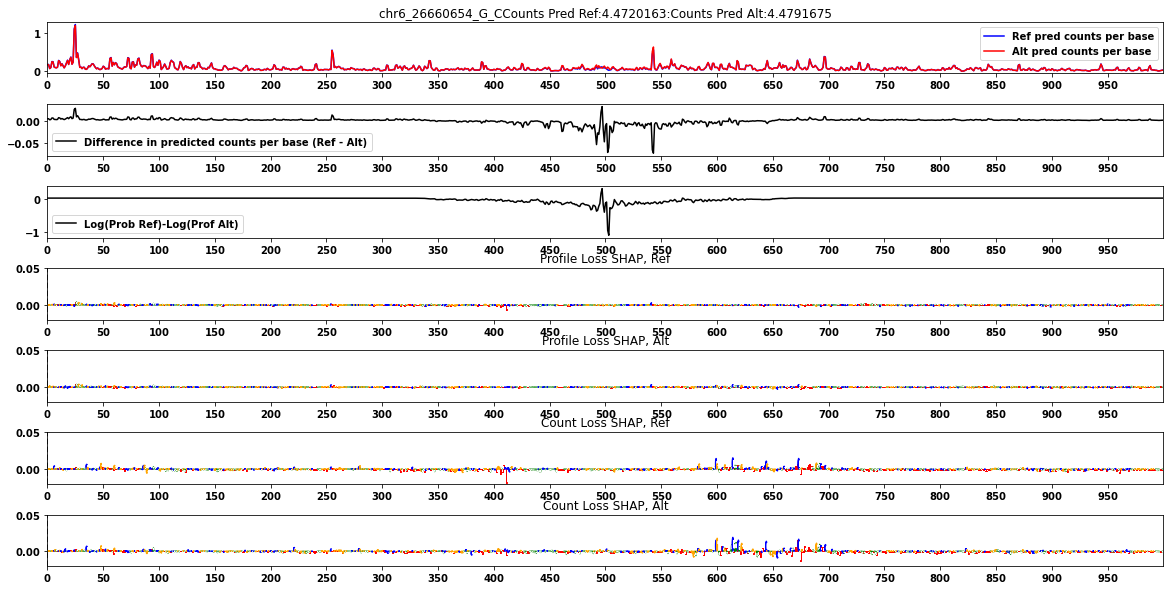

In [34]:
rsid="chr6_26660654_G_C"
cur_seq_ref=np.expand_dims(snp_to_seq[rsid]['ref'],axis=0)
cur_seq_alt=np.expand_dims(snp_to_seq[rsid]['alt'],axis=0)
count_pred_ref=count_preds[rsid]['ref']
count_pred_alt=count_preds[rsid]['alt']
pred_prob_ref=softmax(profile_preds[rsid]['ref'],axis=0)
pred_prob_alt=softmax(profile_preds[rsid]['alt'],axis=0)
profile_explanations_ref=prof_explainer.shap_values([cur_seq_ref])
count_explanations_ref=np.squeeze(count_explainer.shap_values(cur_seq_ref)[0])
profile_explanations_alt=prof_explainer.shap_values([cur_seq_alt])
count_explanations_alt=np.squeeze(count_explainer.shap_values(cur_seq_alt)[0])
make_plot(rsid,
          count_pred_ref,
          count_pred_alt,
          pred_prob_ref,
          pred_prob_alt,
          profile_explanations_ref[:,173:173+1000,:],
          cur_seq_ref[:,173:173+1000,:],
          profile_explanations_alt[:,173:173+1000,:],
          cur_seq_alt[:,173:173+1000,:],
          count_explanations_ref[173:173+1000,:],
          count_explanations_alt[173:173+1000,:],
          xmin=0,
          xmax=1000,
          ymin_prof_shap=-0.02,
          ymin_count_shap=-0.02,
          ymin_perf=-0.02,
          ymax_prof_shap=0.05,
          ymax_count_shap=0.05,
          ymax_perf=0.05)

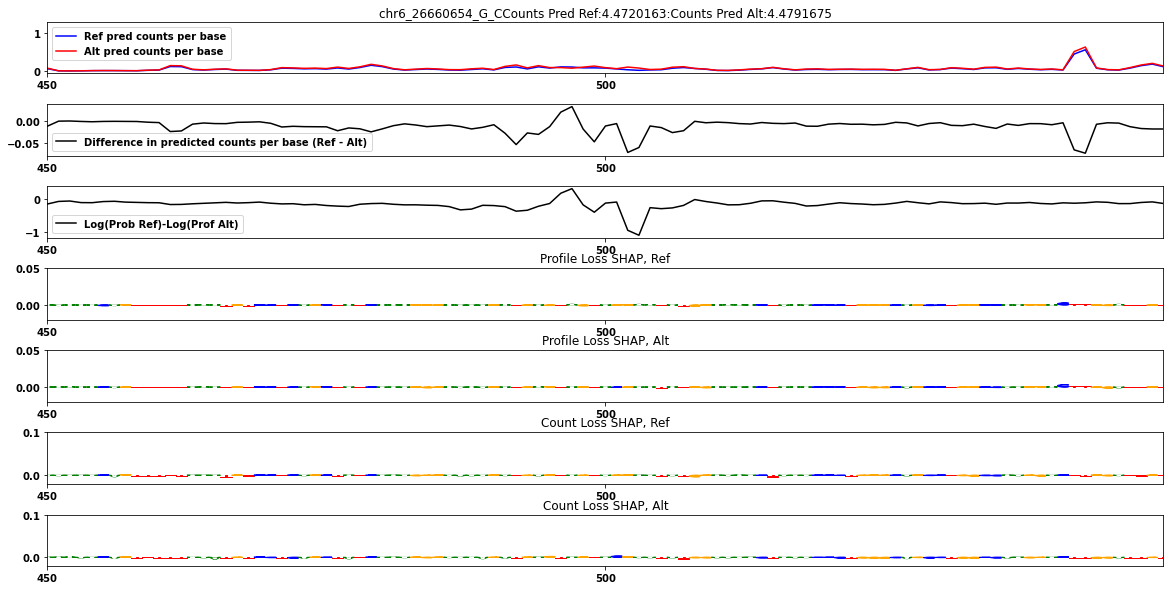

In [35]:
cur_seq_ref=np.expand_dims(snp_to_seq[rsid]['ref'],axis=0)
cur_seq_alt=np.expand_dims(snp_to_seq[rsid]['alt'],axis=0)
count_pred_ref=count_preds[rsid]['ref']
count_pred_alt=count_preds[rsid]['alt']
pred_prob_ref=softmax(profile_preds[rsid]['ref'],axis=0)
pred_prob_alt=softmax(profile_preds[rsid]['alt'],axis=0)
profile_explanations_ref=prof_explainer.shap_values([cur_seq_ref])
count_explanations_ref=np.squeeze(count_explainer.shap_values(cur_seq_ref)[0])
profile_explanations_alt=prof_explainer.shap_values([cur_seq_alt])
count_explanations_alt=np.squeeze(count_explainer.shap_values(cur_seq_alt)[0])
make_plot(rsid,
          count_pred_ref,
          count_pred_alt,
          pred_prob_ref,
          pred_prob_alt,
          profile_explanations_ref[:,173:173+1000,:],
          cur_seq_ref[:,173:173+1000,:],
          profile_explanations_alt[:,173:173+1000,:],
          cur_seq_alt[:,173:173+1000,:],
          count_explanations_ref[173:173+1000,:],
          count_explanations_alt[173:173+1000,:],
          xmin=450,
          xmax=550,
          ymin_prof_shap=-0.02,
          ymin_count_shap=-0.02,
          ymin_perf=-0.02,
          ymax_prof_shap=0.05,
          ymax_count_shap=0.1,
          ymax_perf=0.05)

In [36]:
np.exp(10)

22026.465794806718

In [37]:
merged

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,...,prechipfreq,pvalue,Pos0,rsid,logratio,-log10P,sig,color,abs_logratio,abs_Alt_Minus_Ref
308496,0.001454,5.313743,5.309432,-0.004311,chr20,5654597,22,7,15,C,...,0.796753,0.186451,5654596,chr20_5654596_G_C,-0.153694,0.729435,False,r,0.153694,0.004311
1468408,0.001472,4.272111,4.275629,0.003518,chr8,80935693,22,1,21,C,...,0.932003,1.000000,80935692,chr8_80935692_T_C,0.023648,-0.000000,False,r,0.023648,0.003518
801970,0.001646,4.471915,4.472522,0.000607,chr12,72411308,22,0,22,A,...,0.956238,0.623811,72411307,chr12_72411307_G_A,0.044296,0.204947,False,r,0.044296,0.000607
247085,0.001758,5.284072,5.287243,0.003170,chr7,111720256,40,20,20,C,...,0.387012,0.147114,111720255,chr7_111720255_A_C,0.250443,0.832345,False,r,0.250443,0.003170
100003,0.001767,5.464542,5.465073,0.000531,chr2,33496896,27,0,27,T,...,0.862253,0.043507,33496895,chr2_33496895_C_T,0.146626,1.361445,False,r,0.146626,0.000531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018564,0.310218,3.957546,4.004476,0.046930,chr6,70197789,17,0,17,G,...,0.969822,0.685793,70197788,chr6_70197788_C_G,0.030335,0.163807,False,r,0.030335,0.046930
676272,0.311068,4.035231,4.231188,0.195957,chr7,143187994,16,1,15,C,...,0.852499,0.494701,143187993,chr7_143187993_G_C,0.093993,0.305657,False,r,0.093993,0.195957
1188881,0.346598,4.057447,4.186643,0.129195,chr5,162900839,39,15,24,A,...,0.594889,0.871269,162900838,chr5_162900838_G_A,0.033321,0.059848,False,r,0.033321,0.129195
151997,0.349699,4.485856,4.619947,0.134091,chr6,25223879,69,0,69,T,...,0.955510,0.076872,25223878,chr6_25223878_C_T,0.045049,1.114231,False,r,0.045049,0.134091


In [38]:
merged.to_csv("5e-5.gm12878.nfkb.tsv")

In [39]:
merged.head() 

,JSD,ref,alt,Alt_Minus_Ref,Chr,position,Depth,ALTdepth,REFDepth,ALTallele,...,prechipfreq,pvalue,Pos0,rsid,logratio,-log10P,sig,color,abs_logratio,abs_Alt_Minus_Ref
308496,0.001454,5.313743,5.309432,-0.004311,chr20,5654597,22,7,15,C,...,0.796753,0.186451,5654596,chr20_5654596_G_C,-0.153694,0.729435,False,r,0.153694,0.004311
1468408,0.001472,4.272111,4.275629,0.003518,chr8,80935693,22,1,21,C,...,0.932003,1.000000,80935692,chr8_80935692_T_C,0.023648,-0.000000,False,r,0.023648,0.003518
801970,0.001646,4.471915,4.472522,0.000607,chr12,72411308,22,0,22,A,...,0.956238,0.623811,72411307,chr12_72411307_G_A,0.044296,0.204947,False,r,0.044296,0.000607
247085,0.001758,5.284072,5.287243,0.003170,chr7,111720256,40,20,20,C,...,0.387012,0.147114,111720255,chr7_111720255_A_C,0.250443,0.832345,False,r,0.250443,0.003170
100003,0.001767,5.464542,5.465073,0.000531,chr2,33496896,27,0,27,T,...,0.862253,0.043507,33496895,chr2_33496895_C_T,0.146626,1.361445,False,r,0.146626,0.000531


In [40]:
np.sum(merged['sig']==True)

2826

In [41]:
np.sum(merged['sig']==False)

1551806